# Esperimento  sull'agent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [38]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<StringArray>
[                'qwen-chat-agent-4-v2',
                       'chat-qwen-base',
                    'qwen-chat-agent-6',
                     'qwen-extractor-3',
                     'qwen-extractor-4',
                     'qwen-extractor-2',
 'qwen-chat-extractor-tuned-lora-16-v1',
                 'qwen-chat-agent-5-v1',
                    'qwen-chat-agent-7',
       'qwen-chat-agent-8-wo-embedding',
                   'qwen-chat-agent-12']
Length: 11, dtype: str

In [24]:
df.replace('qwen-chat-agent-4','qwen-chat-agent-5-v1', inplace=True)

,model,language,messaggi,ore_ordinarie_true,ore_straordinarie_true,ore_viaggio_true,note_true,inefficiency_true,inefficiency_note_true,chat_context,...,note_predict,inefficiency_predict,inefficiency_note_predict,REF_INDICE,L_MESSAGGI,TYPE_EVAL,count_function_calls,failure_reason,sentence_similarity_score_note,sentence_similarity_score_inefficiency
0,qwen-chat-agent-4-v2,italian,"[{'content': 'Buongiorno, oggi ho passato l’in...",8.0,1.0,0.0,06/11 Assembly supervision and training to the...,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,supervisione assemblaggio e formazione operato...,0.0,NaN,517,3,normal,1,Agent don't finish with push_data,0.805,NaN
1,qwen-chat-agent-4-v2,italian,[{'content': 'Ho fatto 4 ore straordinarie. Pe...,0.0,4.0,0.0,NaN,4.0,giorno festa locale,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,niente roba da fare. resto in attesa di istruz...,4.0,festa locale,954,2,normal,1,Agent don't finish with push_data,NaN,0.849
2,qwen-chat-agent-4-v2,italian,"[{'content': 'Gentile Team, oggi ho effettuato...",0.0,0.0,16.0,Viaggio Cluj a Ufa,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,625,3,normal,3,NaN,0.000,NaN
3,qwen-chat-agent-4-v2,italian,[{'content': 'Ho lavorato 8 ore ma ho perso 5 ...,8.0,4.5,0.0,Regolazioni ingresso essicatoio ed uscita essi...,5.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,965,3,normal,3,NaN,0.000,NaN
4,qwen-chat-agent-4-v2,italian,[{'content': 'Ho lavorato 8 ore regolari e 3 o...,8.0,3.5,0.0,NaN,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,443,2,normal,1,Agent don't finish with push_data,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,qwen-chat-agent-12,italian,"[{'content': 'Ho lavorato 1 ora di viaggio, ma...",8.0,1.0,1.0,Posizionamento e montaggio bancalini maxicomp...,4.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,completato il posizionamento e montaggio dei b...,4.0,pavimento in cattive condizioni che mi costrin...,762,4,normal,4,NaN,0.885,NaN
7196,qwen-chat-agent-12,spanish,[{'content': 'Trabajo completado: 8 horas ordi...,8.0,0.5,3.0,NaN,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,693,3,normal_w_correction,3,NaN,NaN,NaN
7197,qwen-chat-agent-12,spanish,[{'content': 'Hoy completé 5 horas de trabajo ...,5.0,0.0,1.5,Flauti prima fase,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,721,2,normal_w_correction,2,NaN,0.000,NaN
7198,qwen-chat-agent-12,italian,[{'content': 'Oggi ho svolto 8 ore straordinar...,0.0,8.0,1.0,09.11.2025\r\n- FOUR: Test des vannes de modul...,0.0,NaN,"{\n ""chat-tuned"": [\n {\n ""role"": ""sy...",...,NaN,0.0,NaN,362,3,normal,2,Agent don't finish with push_data,0.000,NaN


In [39]:
target ='base|chat-agent'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-agent-v3-rollout8','qwen-base','qwen-agent-v4-rollout8','qwen-agent-rollout5-v1','qwen-agent-rollout10','qwen-agent-rollout5-wo-embedding',
            'qwen-agent-rollout5-v1(dense reward)'
            ]
models

['qwen-chat-agent-4-v2',
 'chat-qwen-base',
 'qwen-chat-agent-6',
 'qwen-chat-agent-5-v1',
 'qwen-chat-agent-7',
 'qwen-chat-agent-8-wo-embedding',
 'qwen-chat-agent-12']

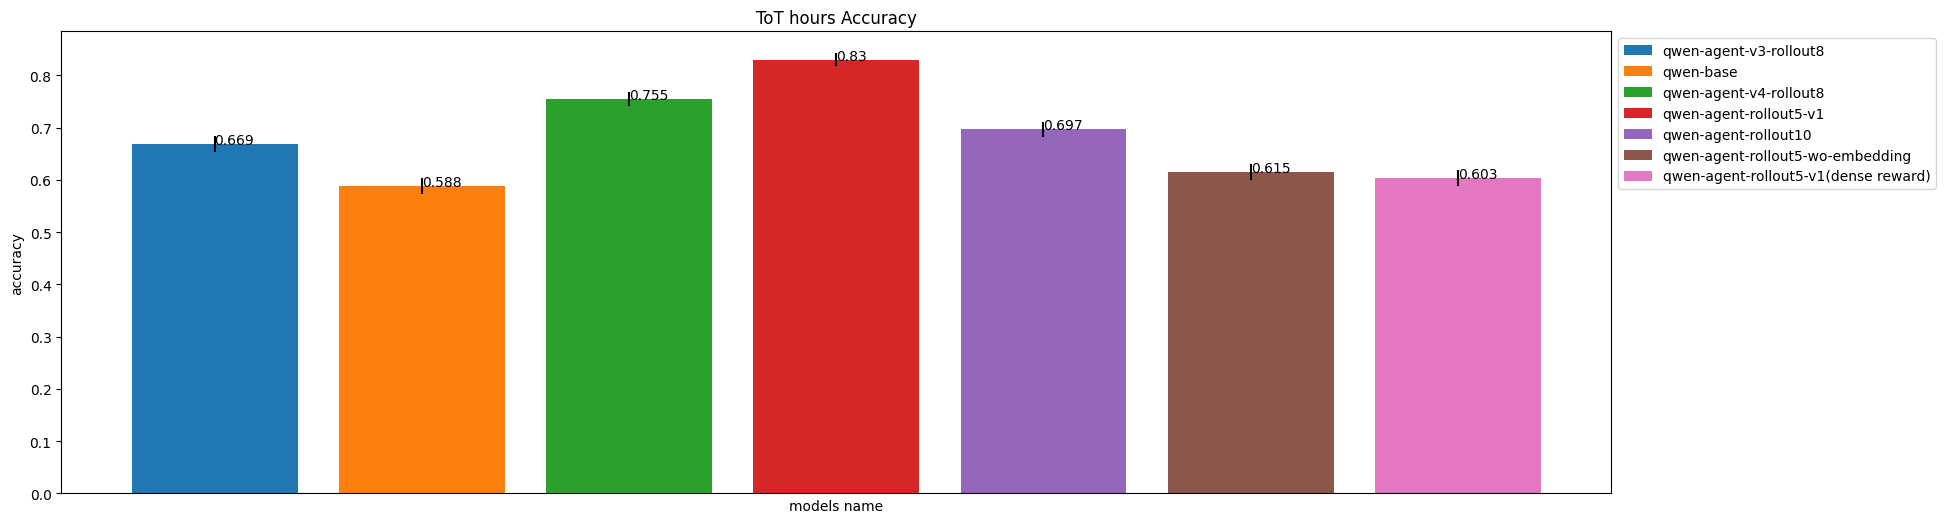

In [40]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

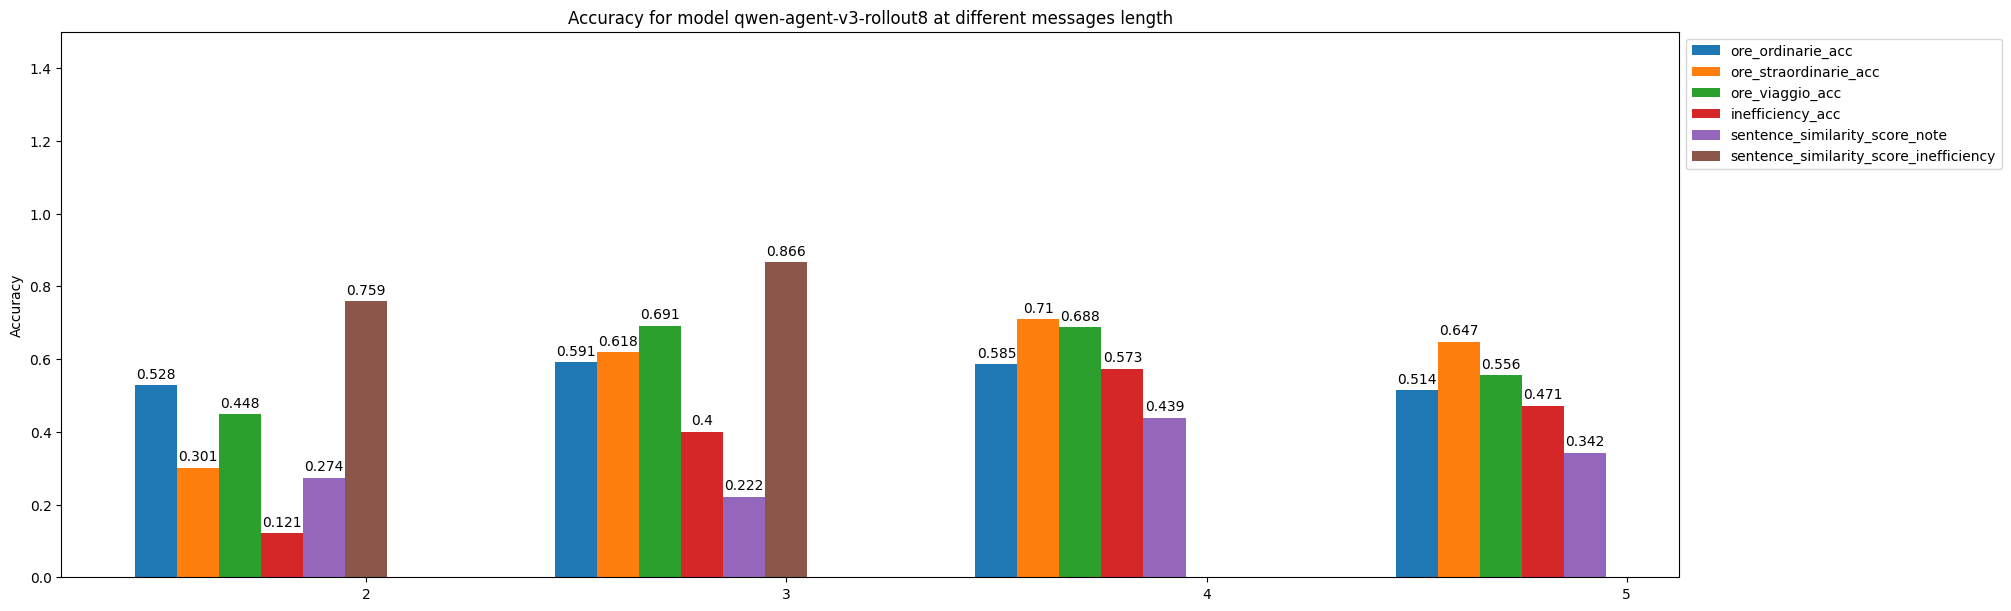

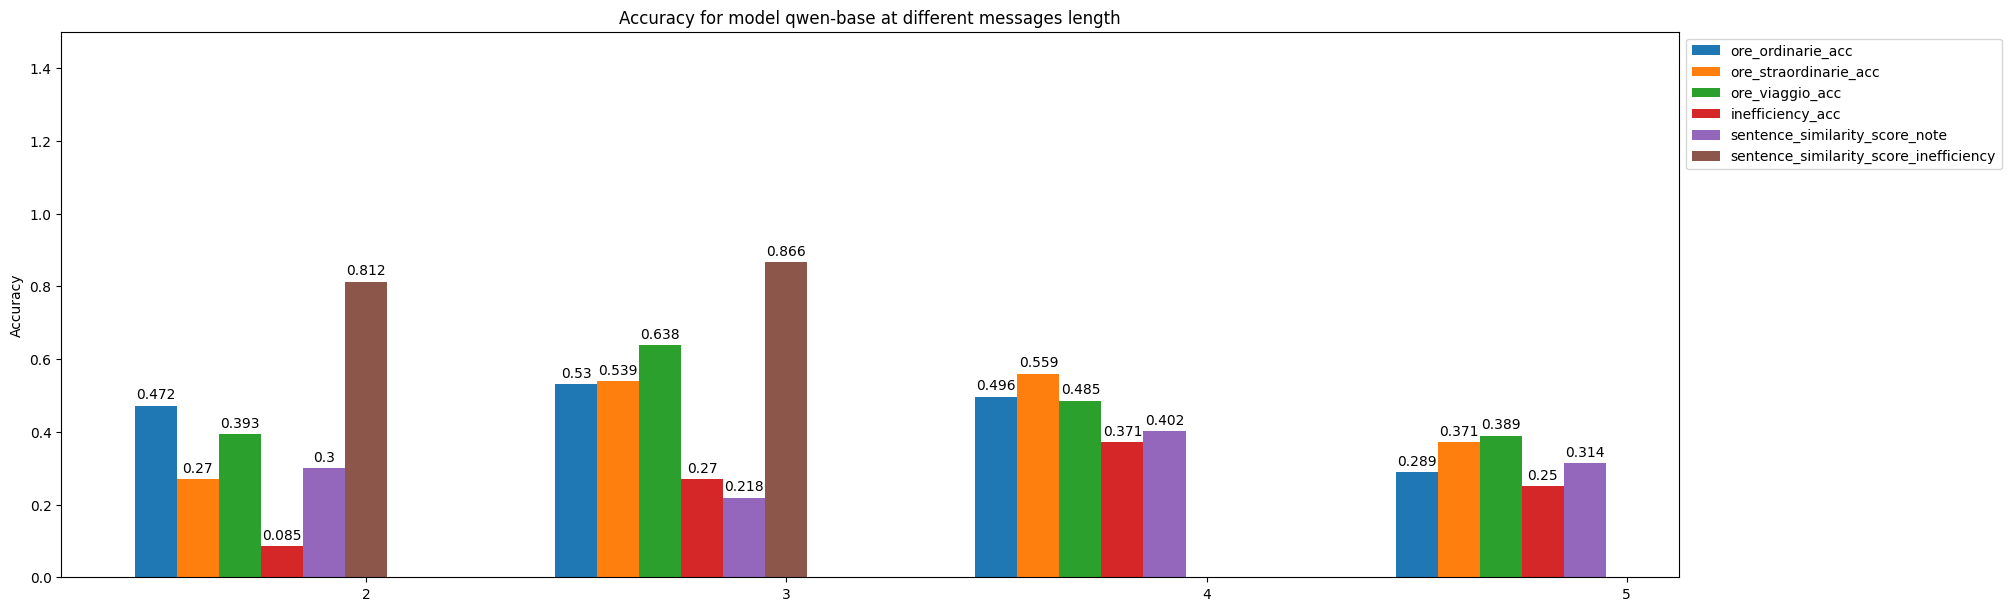

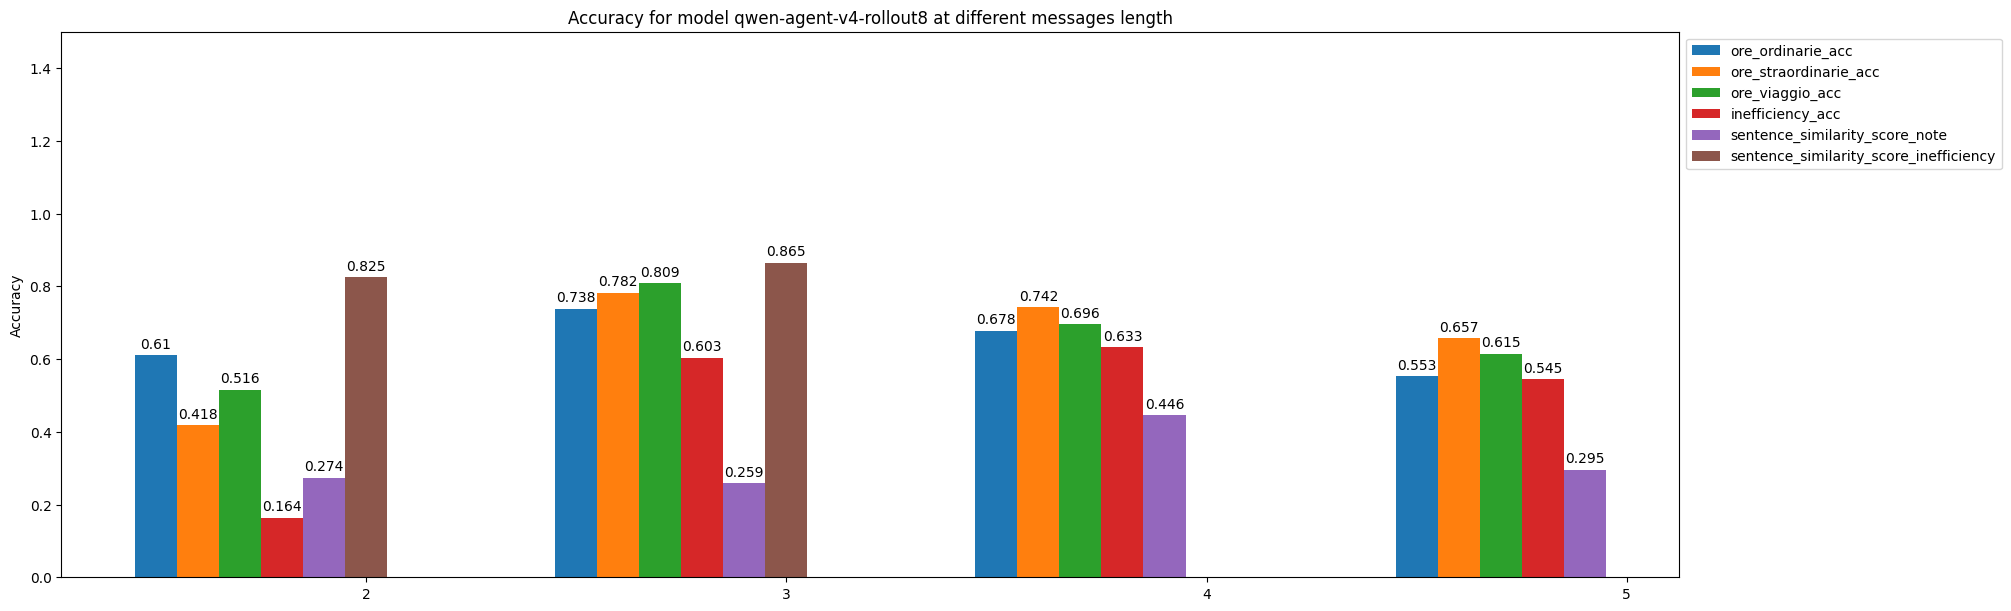

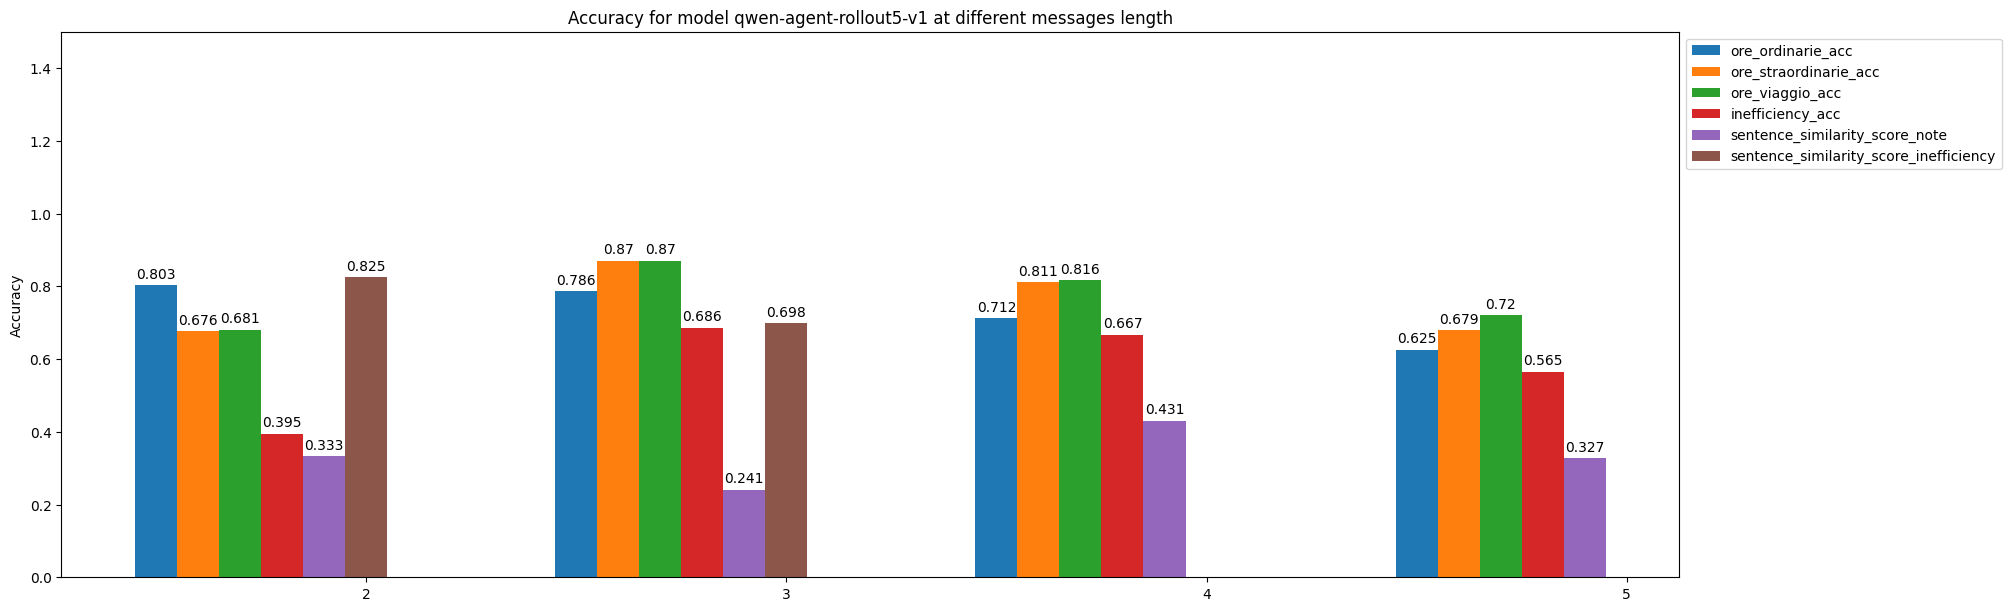

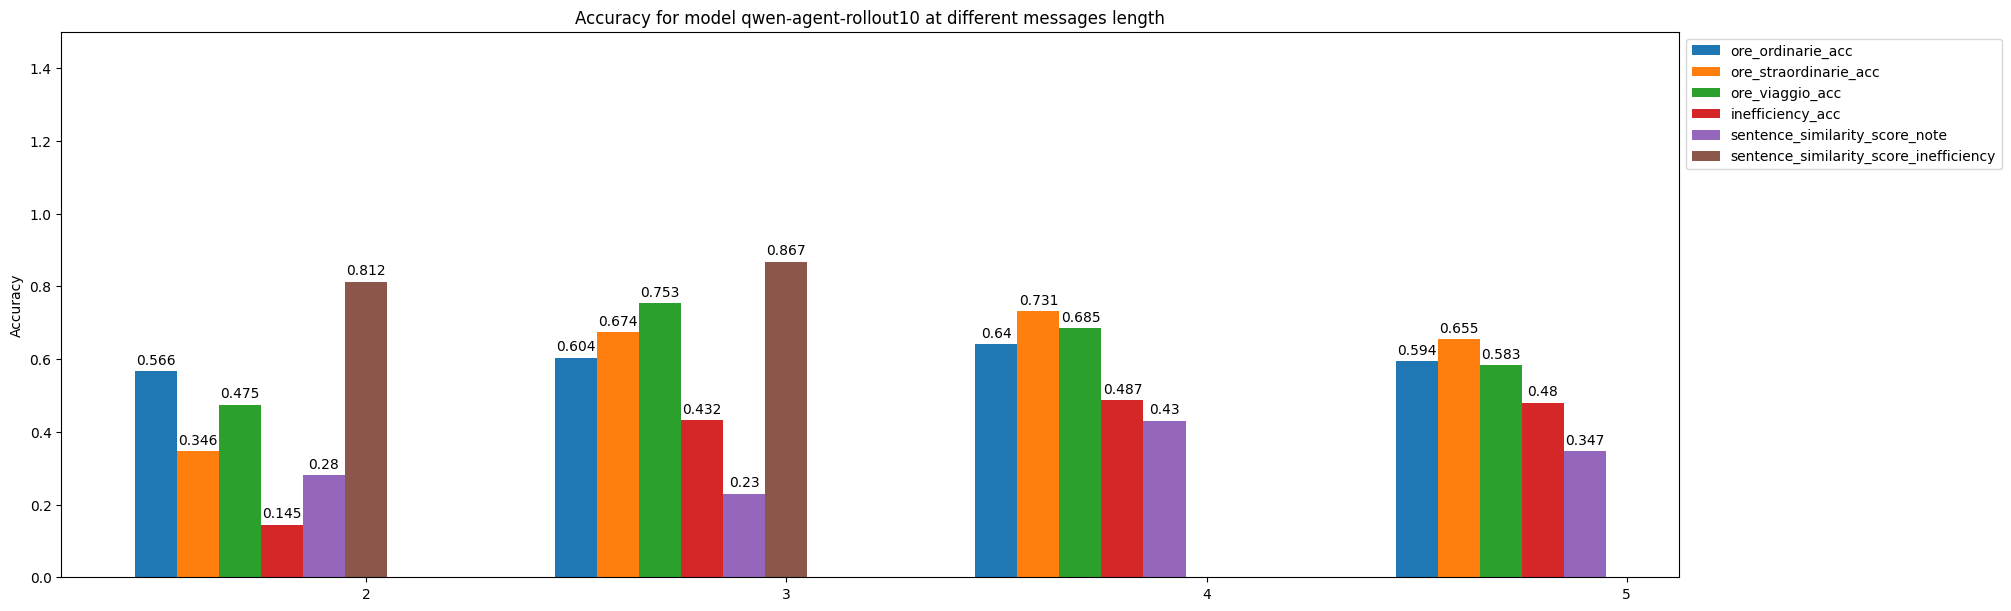

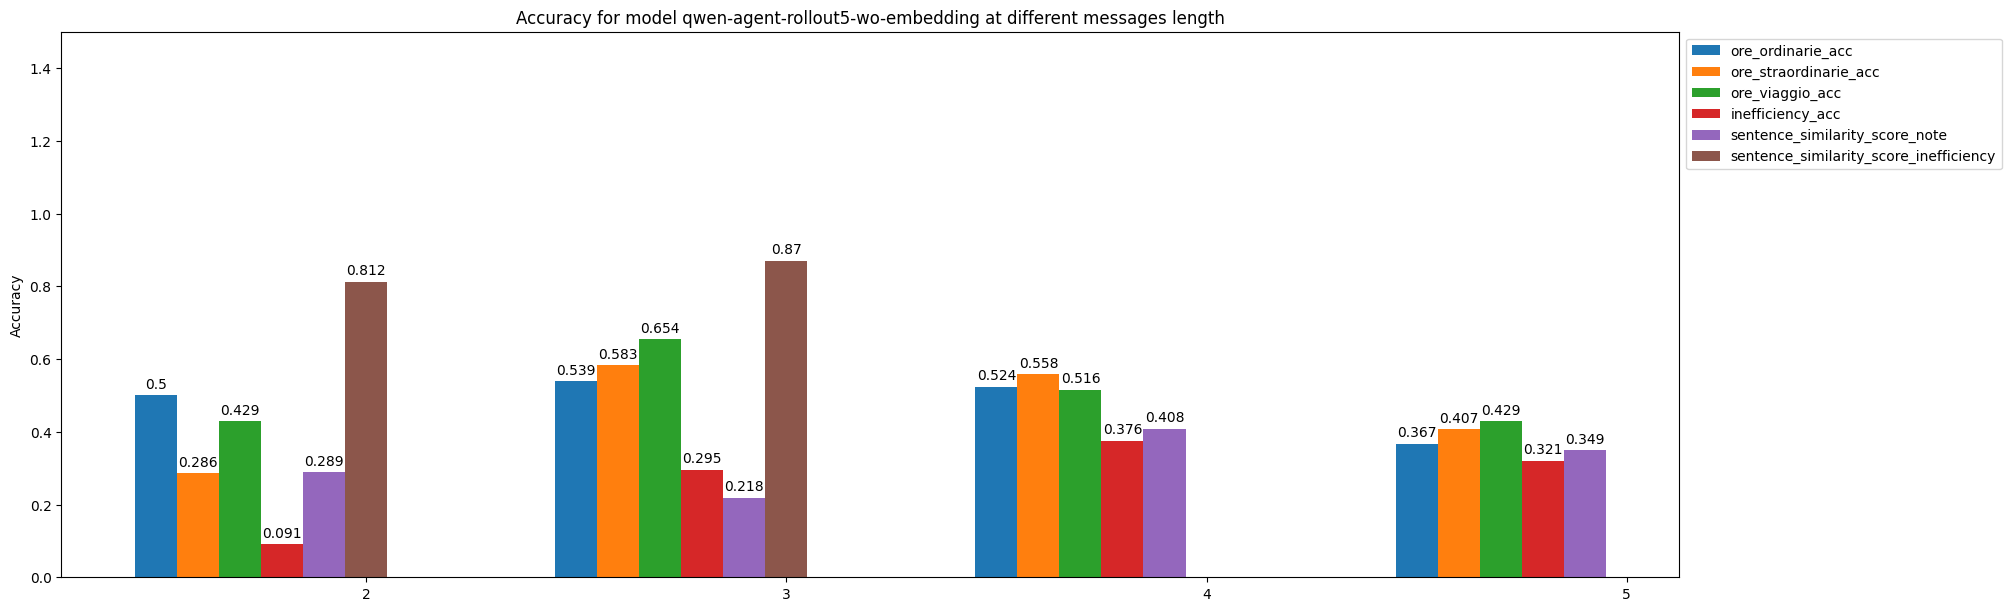

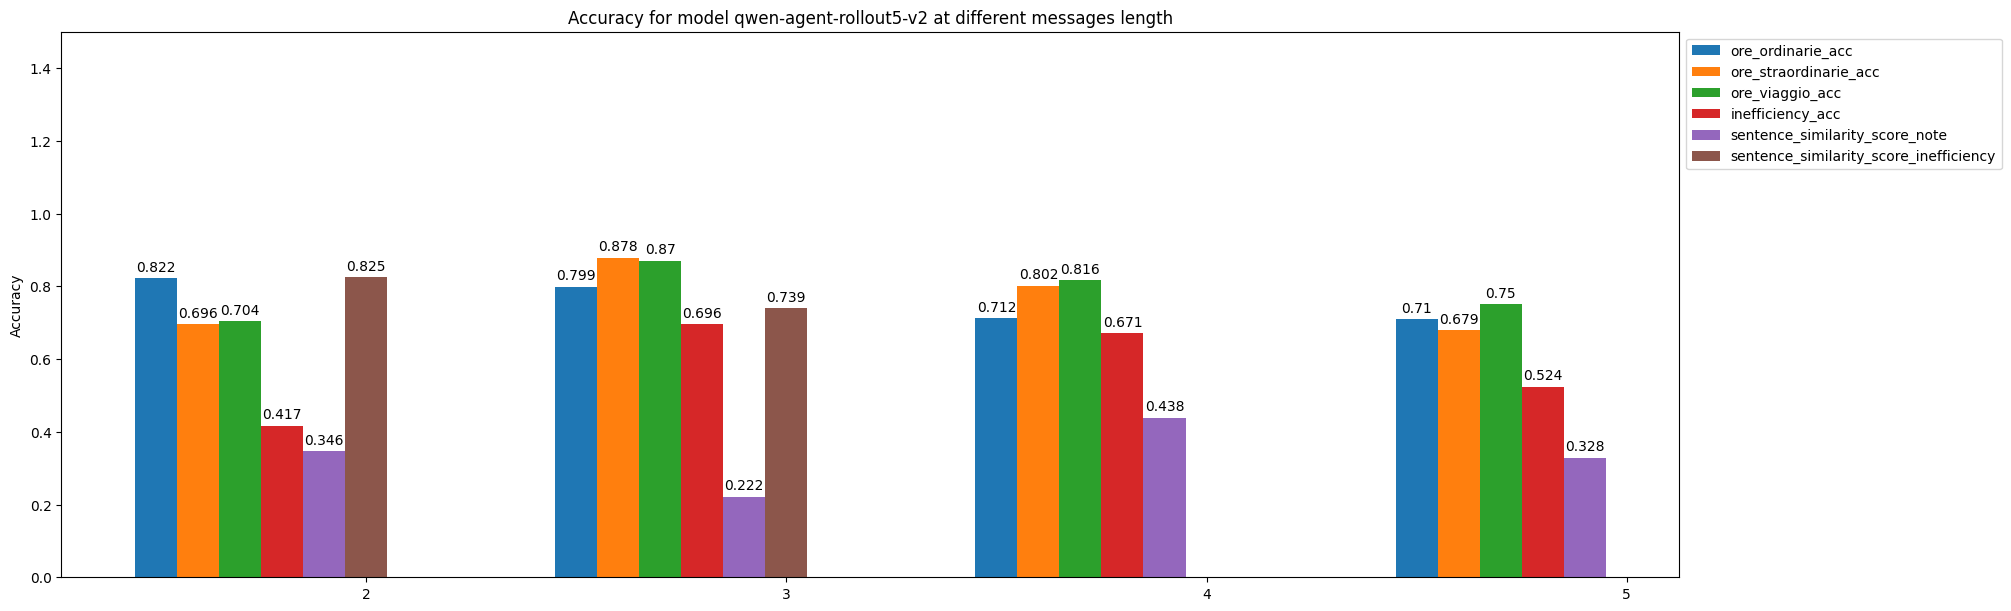

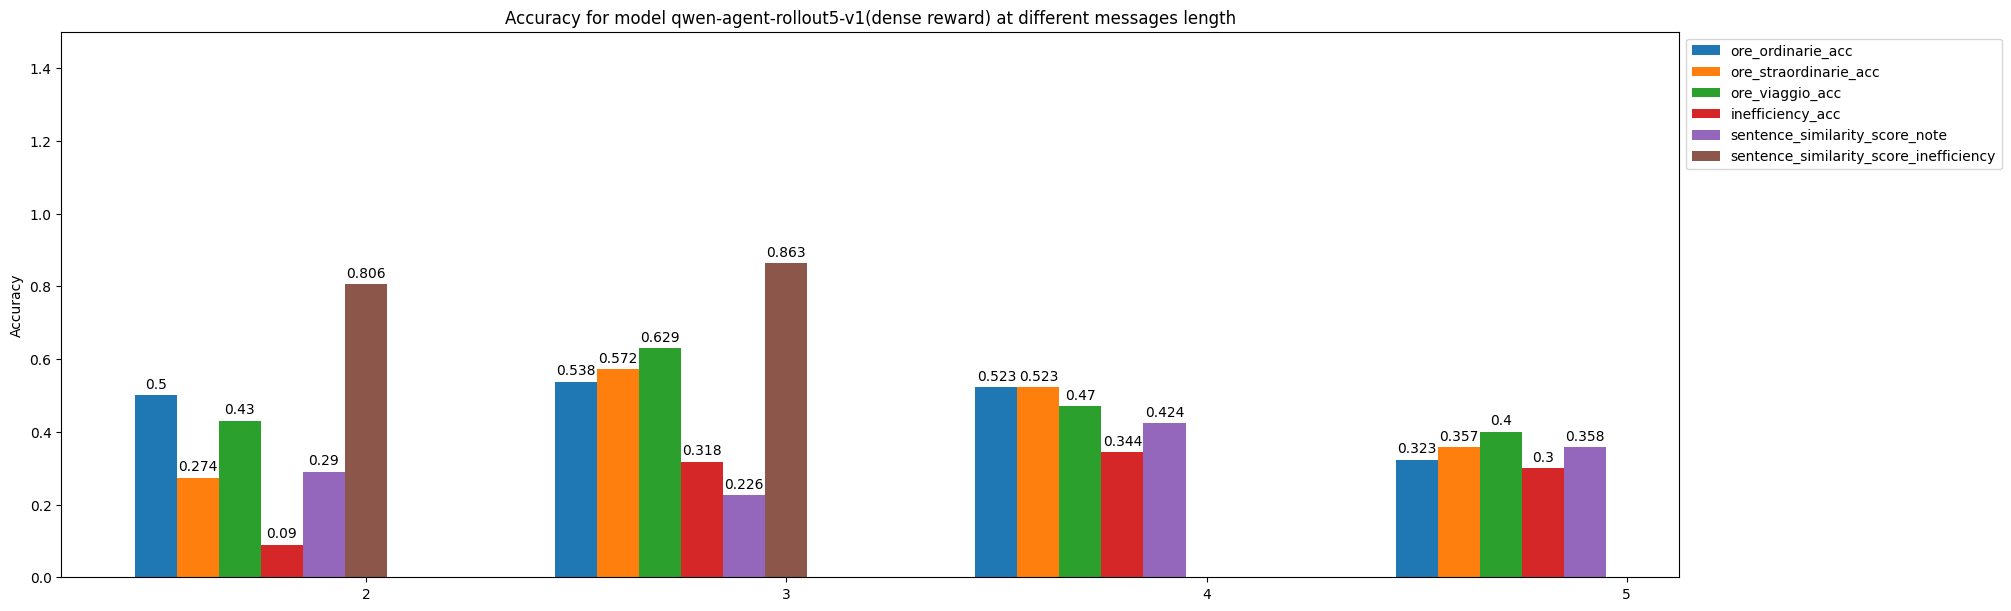

In [32]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

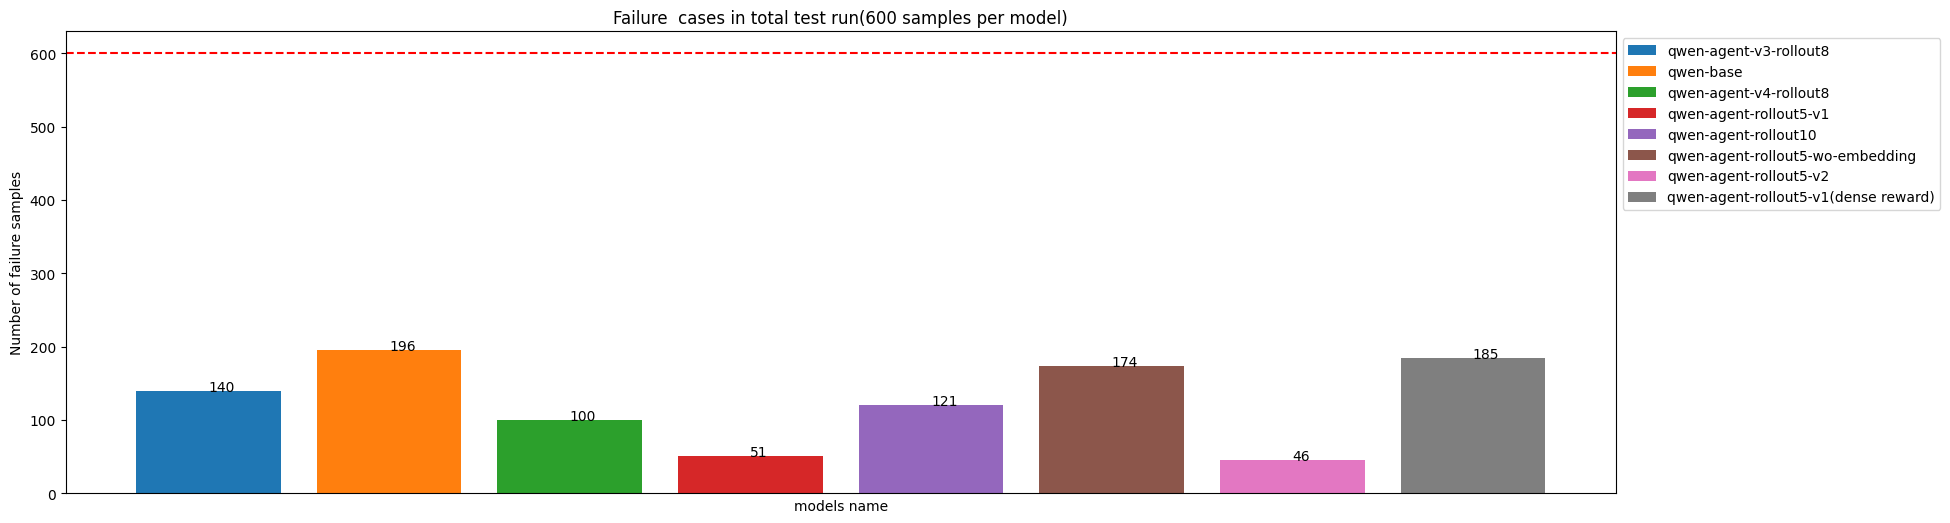

In [31]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run(600 samples per model)")
plt.xlabel("models name")
plt.ylabel("Number of failure samples")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))